## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-03-08 19:24:41.948443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772997882.160582      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772997882.220930      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772997882.716881      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772997882.716928      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772997882.716931      55 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [3]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [4]:
! pip install rasterio

In [5]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('/kaggle/input/datasets/miteshkumar07/image-recognition-dataset/xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [6]:
import json

# Load database
json_file = '/kaggle/input/datasets/miteshkumar07/image-recognition-dataset/xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [7]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [8]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 16871
Number of validation images: 1875


In [9]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

print('Load EfficientNetB0 Model')

# 1. Define Input
inputs = Input(shape=(224, 224, 3))

# 2. Augmentation (Satellite Specific)
# Note: We do NOT use Rescaling(1./255) here. EfficientNet expects 0-255.
x = RandomFlip("horizontal_and_vertical")(inputs)
x = RandomRotation(0.2)(x) 
x = RandomZoom(0.1)(x)

# 3. Load Pre-Trained Base
# include_top=False removes the 1000-class ImageNet layer
# weights='imagenet' loads the pre-learned patterns
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)

# Freeze the base initially
base_model.trainable = False

# 4. Add Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.4)(x) 

outputs = Dense(13, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile with standard LR for the head
opt = Adam(learning_rate=1e-3) 
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Load EfficientNetB0 Model


I0000 00:00:1772997912.714181      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772997912.720584      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha

 Total params: 4,719,280 (18.00 MB)

 Trainable params: 666,125 (2.54 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

In [10]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.losses import CategoricalCrossentropy

# Learning rate is changed to 0.001
opt = RMSprop(
    learning_rate=1e-3, 
    rho=0.9, 
    momentum=0.9, 
    epsilon=1e-07, 
    centered=False
)
loss_fun = CategoricalCrossentropy(label_smoothing=0.1)
model.compile(optimizer=opt, loss=loss_fun, metrics=['accuracy'])

In [11]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.5, patience=5, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=10, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [12]:
def generator_images(objs, batch_size, do_shuffle=False):
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        groups = [objs[i:i+batch_size] for i in range(0, len(objs), batch_size)]
        for group in groups:
            images, labels = [], []
            for (filename, obj) in group:
                # Load image
                images.append(load_geoimage(filename).astype(np.float32))
                probabilities = np.zeros(len(categories))
                probabilities[list(categories.values()).index(obj.category)] = 1
                labels.append(probabilities)
            images = np.array(images).astype(np.float32)
            labels = np.array(labels).astype(np.float32)
            yield images, labels

In [13]:
# Generate the list of objects from annotations
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]
    # Generators
batch_size = 32
train_generator = generator_images(objs_train, batch_size, do_shuffle=True)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)

In [14]:
import math
import numpy as np

print('Training model')
epochs = 30
train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)
# Train for 15-20 epochs to stabilize the new layers
h1 = model.fit(
    train_generator, 
    steps_per_epoch=train_steps, 
    validation_data=valid_generator, 
    validation_steps=valid_steps, 
    epochs=15, 
    callbacks=callbacks, 
    verbose=1
)



# 1. Unfreeze the Brain
base_model.trainable = True

# 2. Freeze the bottom 50 layers (Safe zone)
# Keeps basic edge/corner detectors stable
for layer in base_model.layers[:50]:
    layer.trainable = False

# 3. CRITICAL: Switch to Microscopic LR + Label Smoothing
# This combination gives you the final 1-2% boost
opt_fine = RMSprop(
    learning_rate=1e-5,  # Very slow, very safe
    rho=0.9, 
    momentum=0.9
)
loss_smooth = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=opt_fine, loss=loss_smooth, metrics=['accuracy'])

# 4. Train for 45 more epochs
total_epochs = 60

h2 = model.fit(
    train_generator, 
    steps_per_epoch=train_steps, 
    validation_data=valid_generator, 
    validation_steps=valid_steps, 
    epochs=total_epochs,
    initial_epoch=15, 
    callbacks=callbacks, 
    verbose=1
)
# Best validation model
best_idx = int(np.argmax(h2.history['val_accuracy']))
best_value = np.max(h2.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+16), ' - val_accuracy ' + str(best_value))

Training model
Epoch 1/15


E0000 00:00:1772997938.847170      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772997941.017932     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4989 - loss: 1.8804
Epoch 1: val_accuracy improved from -inf to 0.62400, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 1049s 2s/step - accuracy: 0.4990 - loss: 1.8801 - val_accuracy: 0.6240 - val_loss: 1.4973 - learning_rate: 0.0010
Epoch 2/15
527/528 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6145 - loss: 1.4869
Epoch 2: val_accuracy improved from 0.62400 to 0.63040, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 88s 167ms/step - accuracy: 0.6145 - loss: 1.4869 - val_accuracy: 0.6304 - val_loss: 1.4360 - learning_rate: 0.0010
Epoch 3/15
527/528 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6283 - loss: 1.4663
Epoch 3: val_accuracy improved from 0.63040 to 0.64587, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 78s 148ms/step - accuracy: 0.6283 - loss: 1.4662 - val_accuracy: 0.6459 - val_loss: 1.4144 - learning_rate: 0.0010
Epoch 4/15
527/528 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.64

E0000 00:00:1773000441.427855      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5254 - loss: 1.7320
Epoch 16: val_accuracy improved from 0.68000 to 0.68480, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 143s 219ms/step - accuracy: 0.5256 - loss: 1.7316 - val_accuracy: 0.6848 - val_loss: 1.3027 - learning_rate: 1.0000e-05
Epoch 17/60
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.6869 - loss: 1.3149
Epoch 17: val_accuracy improved from 0.68480 to 0.69600, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 113s 213ms/step - accuracy: 0.6870 - loss: 1.3149 - val_accuracy: 0.6960 - val_loss: 1.2549 - learning_rate: 1.0000e-05
Epoch 18/60
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7244 - loss: 1.2288
Epoch 18: val_accuracy improved from 0.69600 to 0.74133, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 113s 214ms/step - accuracy: 0.7244 - loss: 1.2288 - val_accuracy: 0.7413 - val_loss: 1.1644 - learning_rate: 1.0000e-05
Epoch 19/60
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s

#### Validation
Compute validation metrics.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [16]:
import numpy as np

model.load_weights('model.keras')
y_true, y_pred = [], []
for ann in anns_valid:
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        y_true.append(obj_pred.category)
        y_pred.append(pred_category)

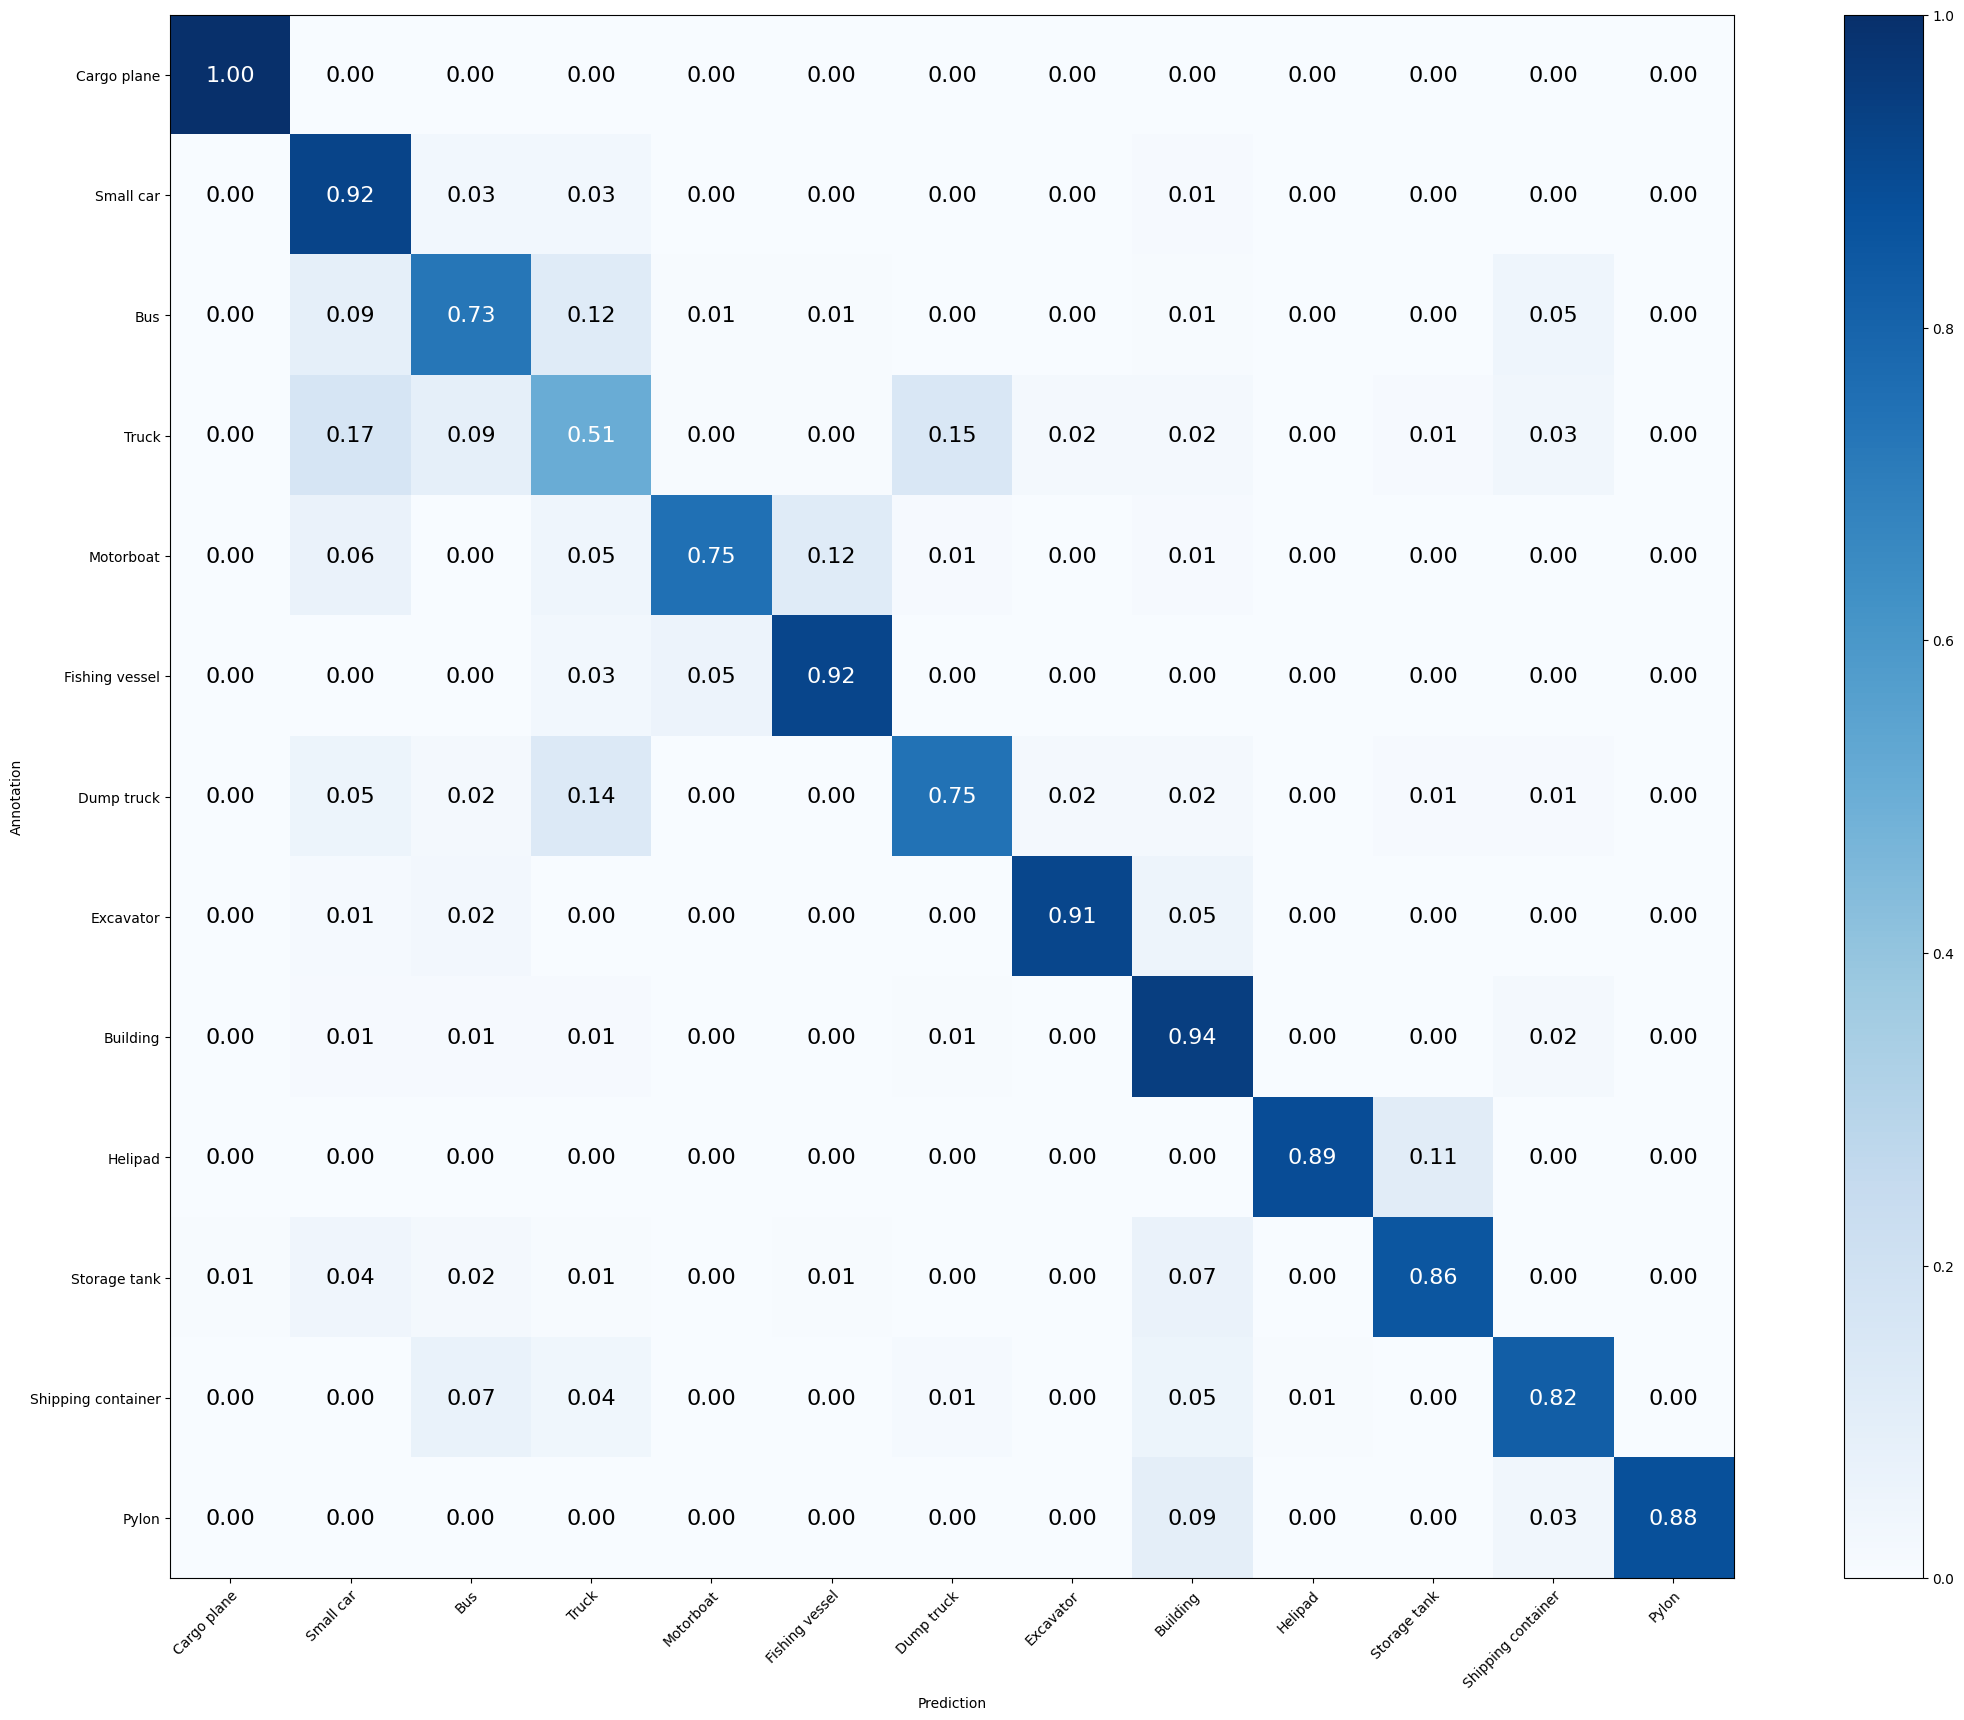

In [17]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [18]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 82.240%
Mean Recall: 83.637%
Mean Precision: 84.757%
> Cargo plane: Recall: 100.000% Precision: 98.333% Specificity: 99.945% Dice: 99.160%
> Small car: Recall: 92.097% Precision: 79.528% Specificity: 94.955% Dice: 85.352%
> Bus: Recall: 72.989% Precision: 72.159% Specificity: 97.119% Dice: 72.571%
> Truck: Recall: 50.622% Precision: 66.304% Specificity: 96.206% Dice: 57.412%
> Motorboat: Recall: 75.229% Precision: 91.111% Specificity: 99.547% Dice: 82.412%
> Fishing vessel: Recall: 91.781% Precision: 79.762% Specificity: 99.057% Dice: 85.350%
> Dump truck: Recall: 74.576% Precision: 67.692% Specificity: 97.610% Dice: 70.968%
> Excavator: Recall: 91.358% Precision: 90.244% Specificity: 99.554% Dice: 90.798%
> Building: Recall: 94.490% Precision: 90.501% Specificity: 97.619% Dice: 92.453%
> Helipad: Recall: 88.889% Precision: 88.889% Specificity: 99.946% Dice: 88.889%
> Storage tank: Recall: 85.526% Precision: 96.296% Specificity: 99.710% Dice: 90.592%
> Shipping container

#### Testing
Try to improve the results provided in the competition.

In [19]:
import os
anns = []
# The "xview_recognition" folder ends at index 83 in this specific Kaggle path
# But it's safer to just look for the word "xview_test"
base_folder = '/kaggle/input/datasets/miteshkumar07/image-recognition-dataset/xview_recognition/'

for (dirpath, dirnames, filenames) in os.walk(base_folder + 'xview_test'):
    for filename in filenames:
        # Get the path relative to the 'xview_recognition' folder
        # This will result in: 'xview_test/filename.tif' or 'xview_test/category/filename.tif'
        rel_path = os.path.relpath(os.path.join(dirpath, filename), base_folder)
        
        image = GenericImage(rel_path)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = os.path.basename(dirpath)
        image.add_object(obj)
        anns.append(image)

print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [20]:
import numpy as np

model.load_weights('model.keras')
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

In [21]:
with open("model2_2run with tran.json", "w") as outfile:
    json.dump(predictions_data, outfile)
